# **MODELADO**

## Setup: imports y carga de checkpoints

Carga `af_modelo` y `dataset_original_copy` ya procesados (generados por `feature_engineering/02_preprocesamiento.py` y `data/02_carga_dataset_desglosado.py`) en vez de re-ejecutar todo el pipeline de datos/EDA/feature engineering.

**Importante:** correr este notebook con el directorio raiz del repositorio como working directory (no `modeling/`), igual que el resto de los scripts.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from prophet import Prophet
import matplotlib.ticker as ticker
from matplotlib.ticker import PercentFormatter
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

af_modelo = pd.read_pickle('data/processed/af_modelo.pkl')
dataset_original_copy = pd.read_pickle('data/processed/dataset_original_copy.pkl')

## Modelos SARIMAX

In [ ]:
af_modelo.isna().sum()

linea                  0
estacion               0
afluencia           3586
media_movil            0
std_movil              0
cambio_%            3059
zscore_movil        3059
anomalia_z             0
estacion_cerrada       0
dtype: int64

In [ ]:
datos = af_modelo[
    (af_modelo['linea']=='linea 1') &
    (af_modelo['estacion']=='balbuena')
]

serie = datos['afluencia'].dropna().sort_index()  

In [ ]:
serie = datos['afluencia'].dropna() 
serie = serie.sort_index()

In [ ]:
print(len(serie))

915


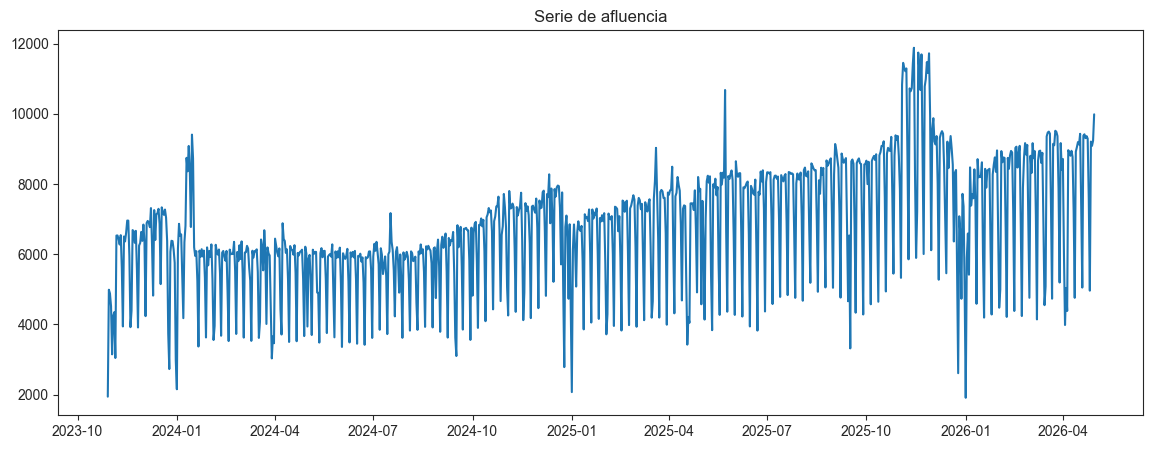

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(serie)
plt.title('Serie de afluencia')
plt.show()

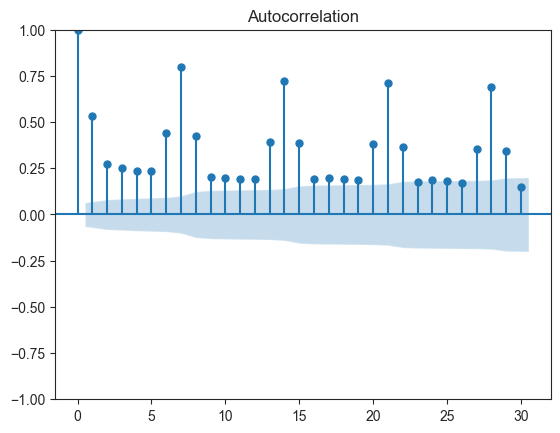

In [ ]:
plot_acf(serie, lags=30)
plt.show()

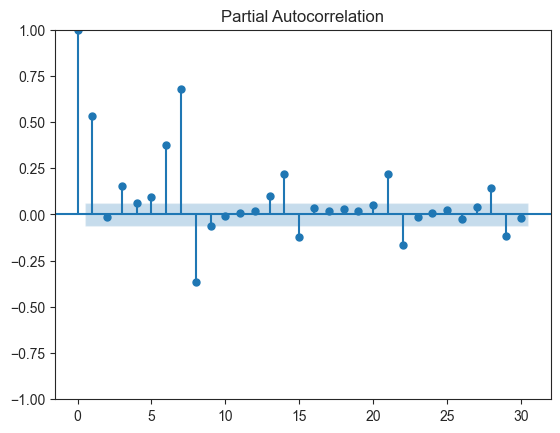

In [ ]:
plot_pacf(serie, lags=30)
plt.show()

In [ ]:
resultado = adfuller(serie)

print("p-value:", resultado[1])

p-value: 0.377163067763964


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(
    serie,
    order=(1,1,1),
    seasonal_order=(0,1,1,7)
)

resultado = modelo.fit()

print(resultado.summary())

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         afluencia   No. Observations:                  915
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -7313.209
Date:                           Sat, 16 May 2026   AIC                          14634.418
Time:                                   12:34:27   BIC                          14653.658
Sample:                               10-29-2023   HQIC                         14641.765
                                    - 04-30-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4701      0.024     19.405      0.000       0.423       0.518
ma.L1         -0.9126      0.015    -60.359

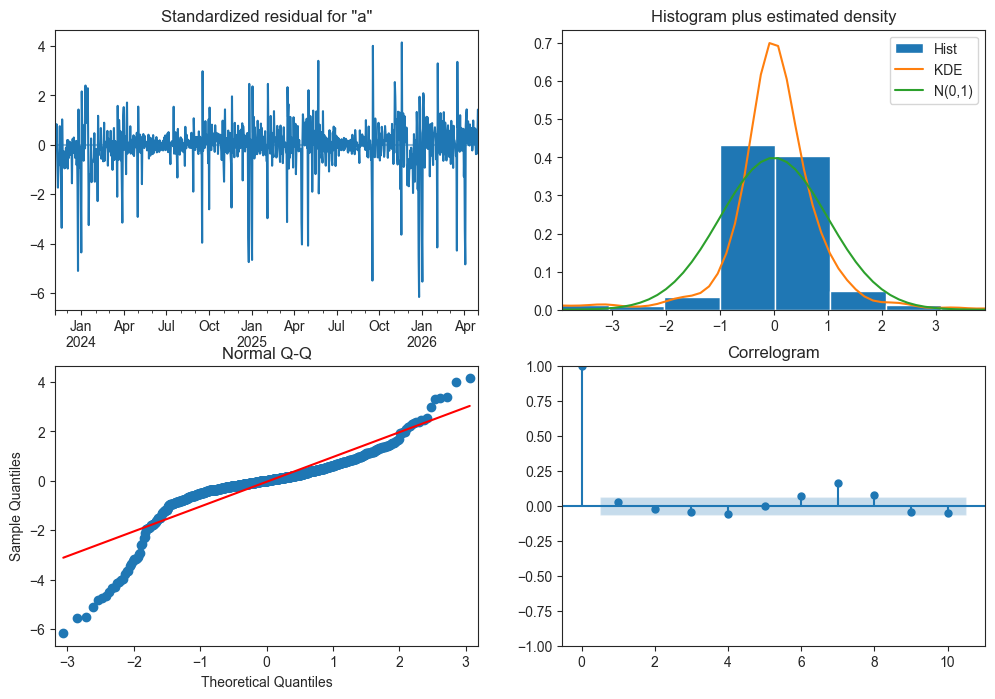

In [ ]:
resultado.plot_diagnostics(figsize=(12,8))
plt.show()

In [ ]:
modelo_auto = auto_arima(
    serie,
    seasonal=True,
    m=7,                 # estacionalidad semanal
    trace=True,          # muestra las pruebas
    stepwise=True,
    suppress_warnings=True
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.07 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=16153.402, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=15203.931, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=15488.321, Time=0.47 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=16151.428, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=16110.696, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=15132.383, Time=0.52 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=15230.230, Time=0.99 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=14924.053, Time=0.75 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=15632.414, Time=0.18 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=15235.830, Time=0.91 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=15475.319, Time=0.39 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=15422.969, Time=1.13 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(2,1,0)(1,0,1)[7] interce

In [ ]:
print(modelo_auto.order)
print(modelo_auto.seasonal_order)

(1, 1, 0)
(1, 0, 1, 7)


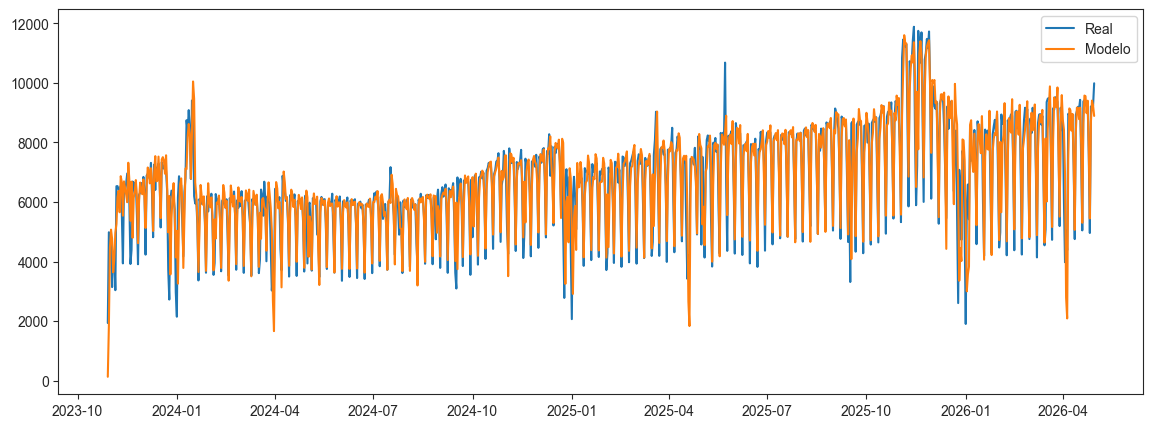

In [ ]:
pred = modelo_auto.predict_in_sample()

plt.figure(figsize=(14,5))
plt.plot(serie, label="Real")
plt.plot(pred, label="Modelo")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(serie, pred)
print(mae)

517.047016436494


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(serie, pred))
print(rmse)

850.3613799081497


In [ ]:
residuos = serie - pred
residuos

fecha
2023-10-29    1804.971308
2023-10-30    3160.215462
2023-10-31     409.336289
2023-11-01    -554.721196
2023-11-02   -1615.279442
                 ...     
2026-04-26    -488.302777
2026-04-27     520.298781
2026-04-28    -318.306512
2026-04-29       0.205388
2026-04-30    1095.381012
Length: 915, dtype: float64

Se puede aplicar una diferenciación estacional, además de incluir modelos estacionales AR(P) o MA(Q) 

In [ ]:
from pmdarima import auto_arima

resultados = {}

for i, (estacion, grupo) in enumerate(af_modelo.groupby("estacion")):

    if i == 2:
        break

    print("Entrenando:", estacion)

    serie = grupo["afluencia"].dropna()

    modelo = auto_arima(
        serie,
        seasonal=True,
        m=7,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        max_p=2,
        max_q=2,
        max_P=1,
        max_Q=1,
        max_d=1,
        max_D=1
    )

    resultados[estacion] = modelo.order, modelo.seasonal_order

Entrenando: acatitla
Entrenando: aculco


# MODELADO SARIMA VS PROPHET CON DIVISION DE ENTRENAMIENTO Y PRUEBA

In [ ]:
af_modelo.isna().sum()
datos = af_modelo[
    (af_modelo['linea']=='linea 2') &
    (af_modelo['estacion']=='cuatro caminos')
]

serie = datos['afluencia'].dropna().sort_index() 

serie = datos['afluencia'].dropna() 
serie = serie.sort_index()

In [ ]:
print(len(serie))

972


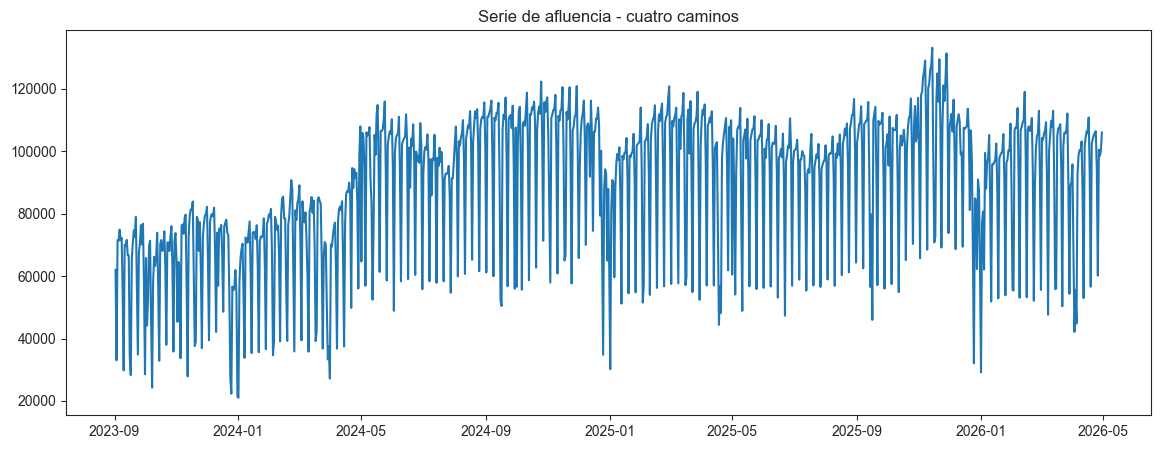

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(serie)
plt.title('Serie de afluencia - cuatro caminos')
plt.show()

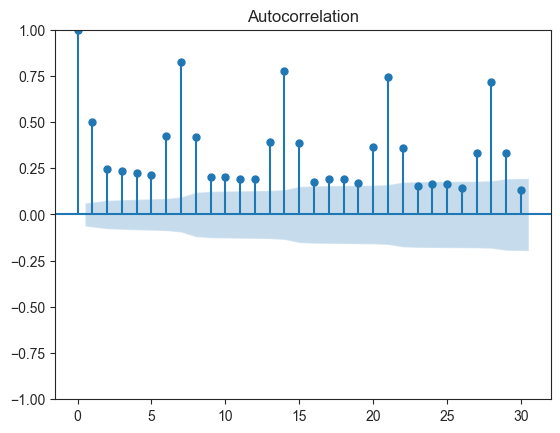

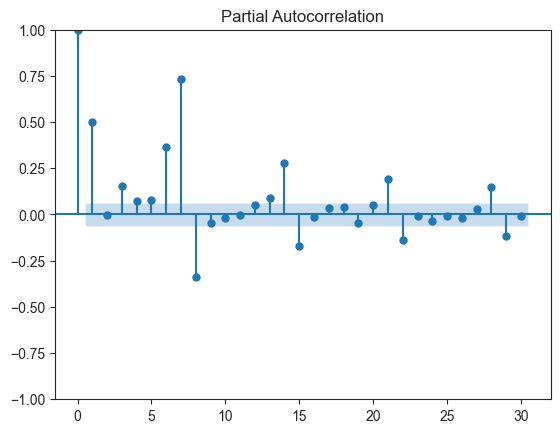

In [ ]:
plot_acf(serie, lags=30)
plot_pacf(serie, lags=30)

plt.show()

Número máximo de rezagos (regla de Schwert): 21

--- ADF Con constante y tendencia ---
  Estadístico ADF    : -2.7452
  p-valor            : 0.2178
  Rezagos usados     : 21
  Valores críticos   : 1%: -3.968  5%: -3.415  10%: -3.130
  Conclusión (5%)    : No se rechaza H0: posible raíz unitaria


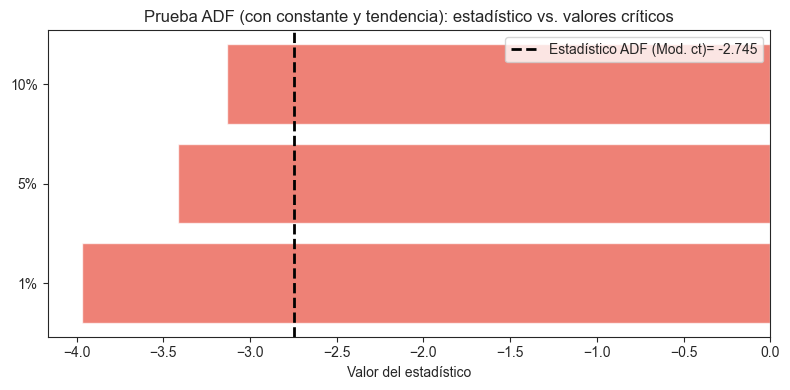

In [ ]:
n_obs = len(serie)
p_max = int(12*(n_obs/100)**0.25) # regla de Schwert
print(f"Número máximo de rezagos (regla de Schwert): {p_max}")

adf_ct = adfuller(serie, maxlag=p_max, autolag='aic', regression='ct')

for label, res in [("Con constante y tendencia",adf_ct)]:
    print(f"\n--- ADF {label} ---")
    print(f"  Estadístico ADF    : {res[0]:.4f}")
    print(f"  p-valor            : {res[1]:.4f}")
    print(f"  Rezagos usados     : {res[2]}")
    print(f"  Valores críticos   : " +
          "  ".join([f"{k}: {v:.3f}" for k, v in res[4].items()]))
    concl = "Se rechaza H0: serie estacionaria" if res[1] < 0.05 else "No se rechaza H0: posible raíz unitaria"
    print(f"  Conclusión (5%)    : {concl}")

# Gráfico: estadístico vs valores críticos
fig, ax = plt.subplots(figsize=(8, 4))
criticos = adf_ct[4]
niveles  = list(criticos.keys())
valores  = list(criticos.values())
colores  = ['#2ecc71' if adf_ct[0] < v else '#e74c3c' for v in valores]
ax.barh(niveles, valores, color=colores, alpha=0.7)
ax.axvline(adf_ct[0], color='black', linewidth=2, linestyle='--',
           label=f'Estadístico ADF (Mod. ct)= {adf_ct[0]:.3f}')
ax.set_xlabel('Valor del estadístico')
ax.set_title('Prueba ADF (con constante y tendencia): estadístico vs. valores críticos')
ax.legend()
plt.tight_layout()
plt.show()

La prueba Dickey-Fuller aumentada con constante y tendencia arrojó un estadístico de -2.6045 y un p-valor de 0.2778. Dado que el p-valor es superior a 0.05 y el estadístico no supera el valor crítico al 5% (-3.415), no se rechaza la hipótesis nula de raíz unitaria. En consecuencia, se concluye que la serie no es estacionaria en niveles.

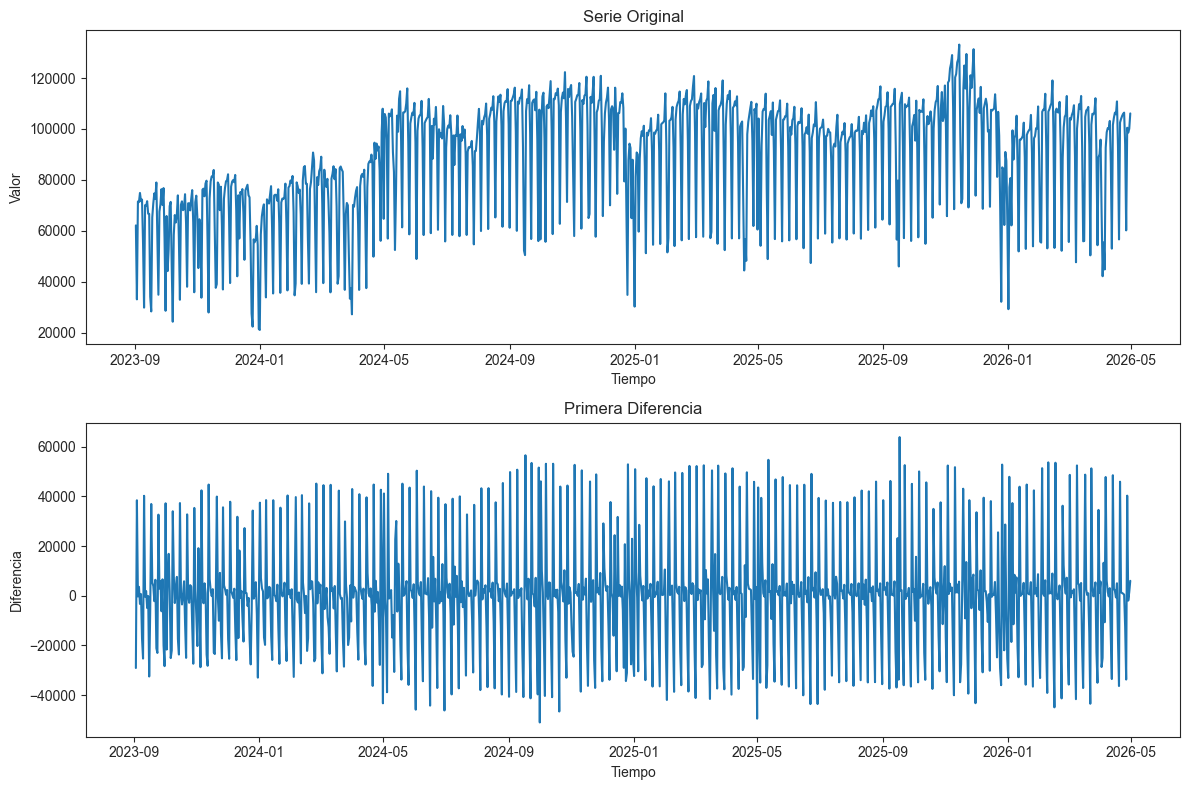

In [ ]:
# 1. Primera diferencia
serie_diff = serie.diff().dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Serie original
axes[0].plot(serie)
axes[0].set_title('Serie Original')
axes[0].set_xlabel('Tiempo')
axes[0].set_ylabel('Valor')

# Serie diferenciada
axes[1].plot(serie_diff)
axes[1].set_title('Primera Diferencia')
axes[1].set_xlabel('Tiempo')
axes[1].set_ylabel('Diferencia')

plt.tight_layout()
plt.show()

Número máximo de rezagos (Schwert): 21

--- ADF: Primera Diferencia ---
Estadístico ADF  : -9.5109
p-valor          : 0.0000
Rezagos usados   : 20
Valores críticos : 1%: -2.5681 | 5%: -1.9413 | 10%: -1.6165
Conclusión       : La serie es estacionaria.


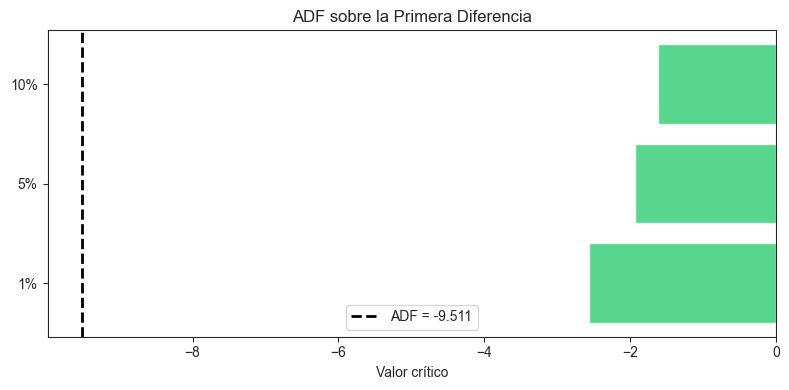

In [ ]:
n_obs = len(serie_diff)
p_max = int(12 * (n_obs / 100) ** 0.25)

print(f"Número máximo de rezagos (Schwert): {p_max}")

adf_diff = adfuller(
    serie_diff,
    maxlag=p_max,
    autolag='AIC',
    regression='n'
)

print("\n--- ADF: Primera Diferencia ---")
print(f"Estadístico ADF  : {adf_diff[0]:.4f}")
print(f"p-valor          : {adf_diff[1]:.4f}")
print(f"Rezagos usados   : {adf_diff[2]}")
print(
    "Valores críticos : " +
    " | ".join(
        [f"{k}: {v:.4f}" for k, v in adf_diff[4].items()]
    )
)

if adf_diff[1] < 0.05:
    print("Conclusión       : La serie es estacionaria.")
else:
    print("Conclusión       : La serie aún no es estacionaria.")

fig, ax = plt.subplots(figsize=(8, 4))

criticos = adf_diff[4]
niveles = list(criticos.keys())
valores = list(criticos.values())

colores = [
    '#2ecc71' if adf_diff[0] < v else '#e74c3c'
    for v in valores
]

ax.barh(niveles, valores, color=colores, alpha=0.8)
ax.axvline(
    adf_diff[0],
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'ADF = {adf_diff[0]:.3f}'
)

ax.set_xlabel('Valor crítico')
ax.set_title('ADF sobre la Primera Diferencia')
ax.legend()

plt.tight_layout()
plt.show()

se determina que el orden de diferenciación no estacional es:

d=1

Este es uno de los parámetros clave del modelo SARIMAX:

p: orden autorregresivo
d: diferenciación
q: media móvil

Y, si hay estacionalidad:

P, D, Q, s

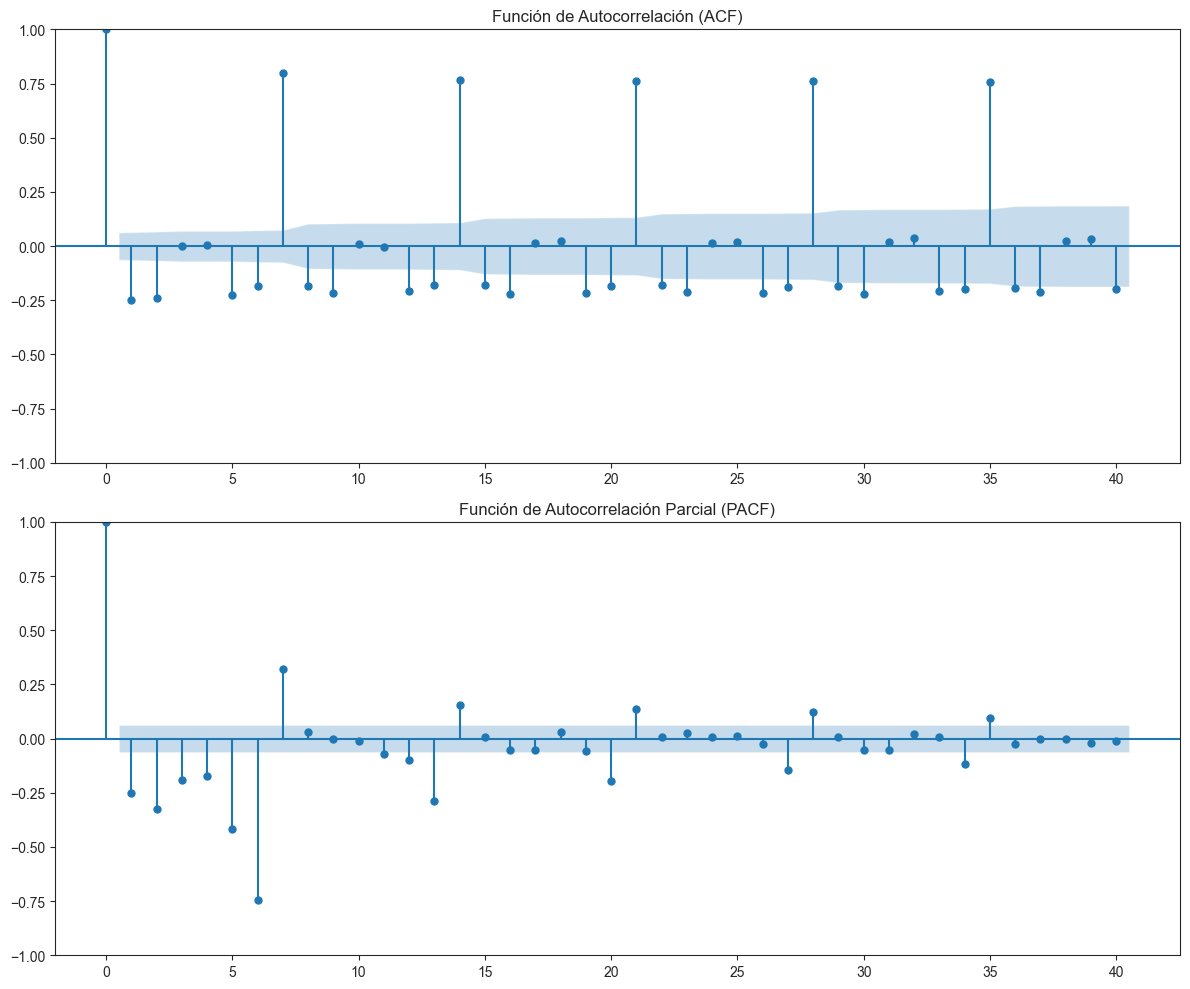

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

plot_acf(
    serie_diff,
    lags=40,
    ax=axes[0]
)
axes[0].set_title('Función de Autocorrelación (ACF)')

plot_pacf(
    serie_diff,
    lags=40,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

En los primeros rezagos:

La ACF muestra un pico negativo en lag 1.
La PACF también presenta un pico significativo en lag 1.

Esto sugiere que debes probar modelos pequeños, como:

AR(1)
MA(1)
ARMA(1,1)
Componente estacional

Los picos en múltiplos de 7 son muy notorios:

La ACF sugiere un componente MA estacional.
La PACF muestra también cierta persistencia estacional.

Un excelente punto de partida es:

P = 1
Q = 1
Modelo inicial recomendado

SARIMA(1,1,1)×(1,0,1)
7
	​


Este suele funcionar muy bien con patrones semanales.

In [ ]:
# ============================================
# AutoARIMA para selección automática
# ============================================

from pmdarima import auto_arima

modelo_auto = auto_arima(
    serie,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=1,                  # Ya determinado con ADF
    seasonal=True,
    m=7,                  # Estacionalidad semanal
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    D=None,               # Determinar automáticamente
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

print(modelo_auto.summary())
print(f"\nMejor modelo encontrado: {modelo_auto.order} x {modelo_auto.seasonal_order}")
print(f"AIC: {modelo_auto.aic():.2f}")
print(f"BIC: {modelo_auto.bic():.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=22259.229, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=21575.418, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=21592.045, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22257.233, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=22197.653, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=21536.193, Time=0.18 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=21455.316, Time=0.91 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=21329.559, Time=0.63 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=21812.001, Time=0.07 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=21351.136, Time=0.94 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=21704.512, Time=0.13 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=21467.374, Time=1.20 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=21425.071, Time=0.65 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=21394.463, Time=0.22 sec
 ARIMA(1,1,1)(1,0,1

In [ ]:
# División 80-20
train_size = int(len(serie) * 0.85)

train = serie[:train_size]
test = serie[train_size:]

print(f"Train: {len(train)}")
print(f"Test: {len(test)}")

Train: 826
Test: 146


    train_log,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),   # <- D=1 para estacionalidad semanal
    enforce_stationarity=False,
    enforce_invertibility=False

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(
    train,
    order=(1,1,0),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarimax = modelo_sarimax.fit(disp=False)

pred_sarimax = resultado_sarimax.forecast(steps=len(test))

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



In [ ]:
# Pronóstico para el horizonte del conjunto de prueba
forecast = resultado_sarimax.get_forecast(steps=len(test))

predicciones = forecast.predicted_mean
intervalos = forecast.conf_int()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np

mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 19,256.52
RMSE: 23,076.33
MAPE: 23.85%


## PROPHET

In [ ]:
# Prophet necesita formato ds/y
df_prophet = pd.DataFrame({
    'ds': serie.index,
    'y': serie.values
})

# División temporal idéntica
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

# Entrena
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.03
)
modelo_prophet.add_country_holidays(country_name='MX')

modelo_prophet.fit(train_prophet)

# Predecir SOLO test
future = test_prophet[['ds']]

forecast = modelo_prophet.predict(future)

pred_prophet = forecast['yhat'].values

13:16:40 - cmdstanpy - INFO - Chain [1] start processing
13:16:40 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
def metricas_series_tiempo(y_real, y_pred):
    # MAE
    # Error absoluto promedio
    mae = mean_absolute_error(y_real, y_pred)

    # MSE
    # Error cuadrático medio
    mse = mean_squared_error(y_real, y_pred)

    # RMSE
    # Penaliza errores grandes
    rmse = np.sqrt(mse)

    # MAPE
    # Error porcentual medio
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    # SMAPE
    # Más estable que MAPE
    smape = np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred))) * 100

    medae = median_absolute_error(y_real, y_pred)

    # R cuadrada
    r2 = r2_score(y_real, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "SMAPE": smape,
        "R2": r2,
        "MedAE": medae
        }

metricas_sarimax = metricas_series_tiempo(test, pred_sarimax)
metricas_prophet = metricas_series_tiempo(test, pred_prophet)

print("\n========== SARIMAX ==========\n")

for k, v in metricas_sarimax.items():
    if k in ["MAPE", "SMAPE"]:
        print(f"{k:<10}: {v:.2f}%")
    else:
        print(f"{k:<10}: {v:.2f}")



print("\n========== PROPHET ==========\n")

for k, v in metricas_prophet.items():
    if k in ["MAPE", "SMAPE"]:
        print(f"{k:<10}: {v:.2f}%")
    else:
        print(f"{k:<10}: {v:.2f}")


========== SARIMAX ==========

MAE       : 19256.52
MSE       : 532516821.42
RMSE      : 23076.33
MAPE      : 23.85%
SMAPE     : 24.56%
R2        : -0.29
MedAE     : 18475.88

========== PROPHET ==========

MAE       : 5468.94
MSE       : 87235951.79
RMSE      : 9340.02
MAPE      : 7.74%
SMAPE     : 6.89%
R2        : 0.79
MedAE     : 3374.76


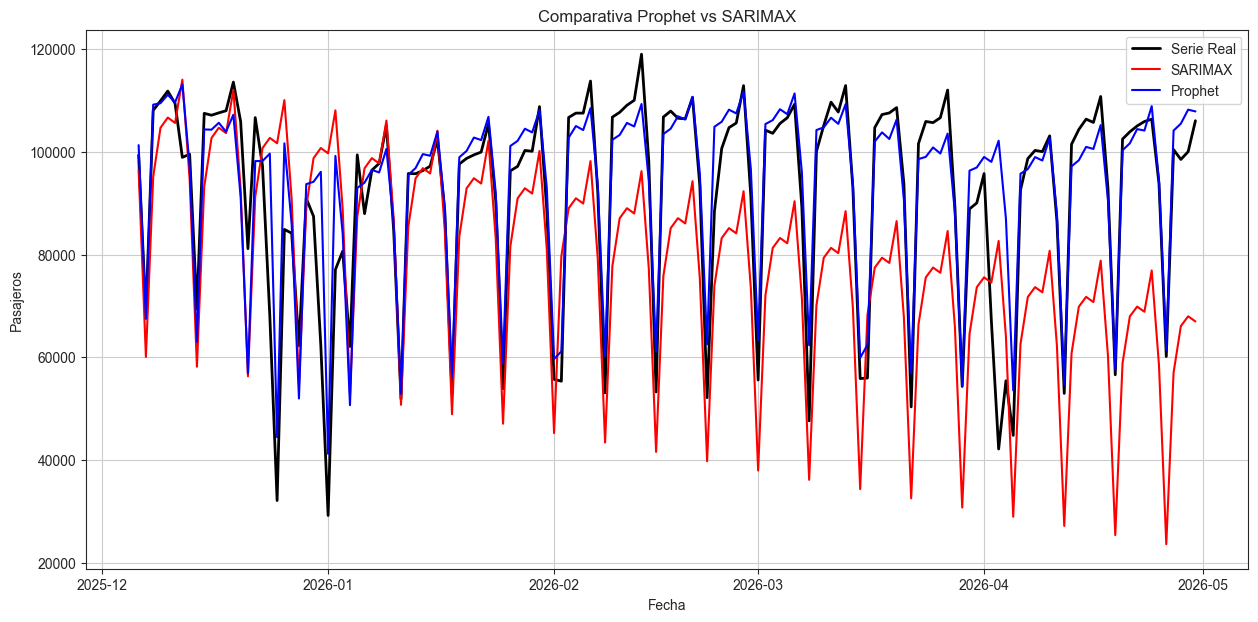

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(test.index,
    test.values,
    label='Serie Real',
    color='black',
    linewidth=2)

plt.plot(test.index,
    pred_sarimax,
    label='SARIMAX',
    color='red')

plt.plot(test.index,
    pred_prophet,
    label='Prophet',
    color='blue')

plt.title('Comparativa Prophet vs SARIMAX')
plt.ylabel('Pasajeros')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True)
plt.show()

# **Detección de anomalías**

In [ ]:
# Guardar predicciones dentro de test_prophet
test_prophet['yhat'] = forecast['yhat'].values

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/394839645.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3201787290.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3201787290.py:41: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



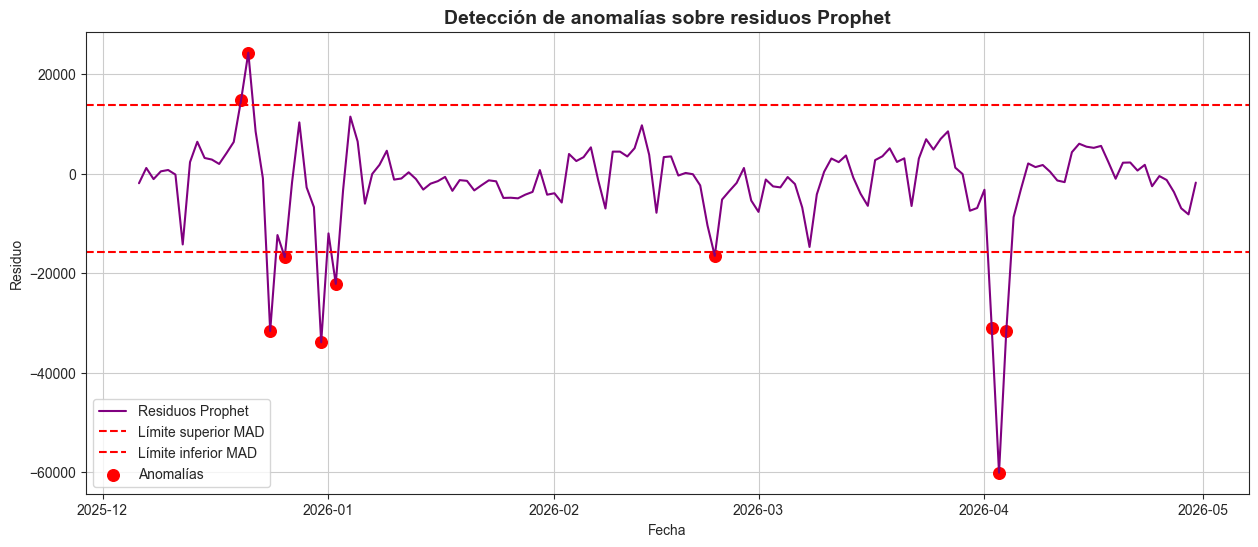

Total anomalías detectadas: 10


In [ ]:
# RESIDUOS DE PROPHET

test_prophet['residuo'] = (test_prophet['y'] - test_prophet['yhat'])

# MAD ROBUSTO SOBRE RESIDUOS
mediana_residuos = np.median(test_prophet['residuo'])

mad_residuos = np.median(np.abs(test_prophet['residuo'] - mediana_residuos))

sigma_residuos = mad_residuos * 1.4826
factor_prophet = 3

limite_superior = (mediana_residuos + factor_prophet * sigma_residuos)

limite_inferior = (mediana_residuos - factor_prophet * sigma_residuos)

# DETECCIÓN DE ANOMALÍAS

test_prophet['anomalia'] = ((test_prophet['residuo'] > limite_superior) | (test_prophet['residuo'] < limite_inferior))

# GRÁFICA RESIDUOS + MAD
plt.figure(figsize=(15,6))

plt.plot(test_prophet['ds'],
    test_prophet['residuo'],
    label='Residuos Prophet',
    color='purple')

plt.axhline(limite_superior,
    color='red',
    linestyle='--',
    label='Límite superior MAD')

plt.axhline(limite_inferior,
    color='red',
    linestyle='--',
    label='Límite inferior MAD')

plt.scatter(test_prophet.loc[test_prophet['anomalia'], 'ds'],
    test_prophet.loc[test_prophet['anomalia'], 'residuo'],
    color='red',
    s=70,
    label='Anomalías')

plt.title('Detección de anomalías sobre residuos Prophet', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.legend()
plt.grid(True)
plt.show()


print(f"Total anomalías detectadas: {test_prophet['anomalia'].sum()}")

La idea sería:

Prophet modela: tendencia, estacionalidad semanal,patrones temporales.
Luego analizas los residuos:

residuo=yreal −ypredicho
	​

Sobre esos residuos aplicas MAD robusto.

Eso es muchísimo mejor que aplicar MAD directamente sobre la serie original, porque la serie del metro no es estacionaria:

tiene tendencia, días de semana vs domingo,
variaciones normales del sistema. Entonces, si aplicas MAD directamente a la serie:

muchos domingos parecen “anómalos” aunque son normales, cambios estacionales normales generan falsos positivos.

En cambio, sobre residuos:

Prophet ya explica el comportamiento esperado y MAD detecta únicamente desviaciones inesperadas.

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/3857378410.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

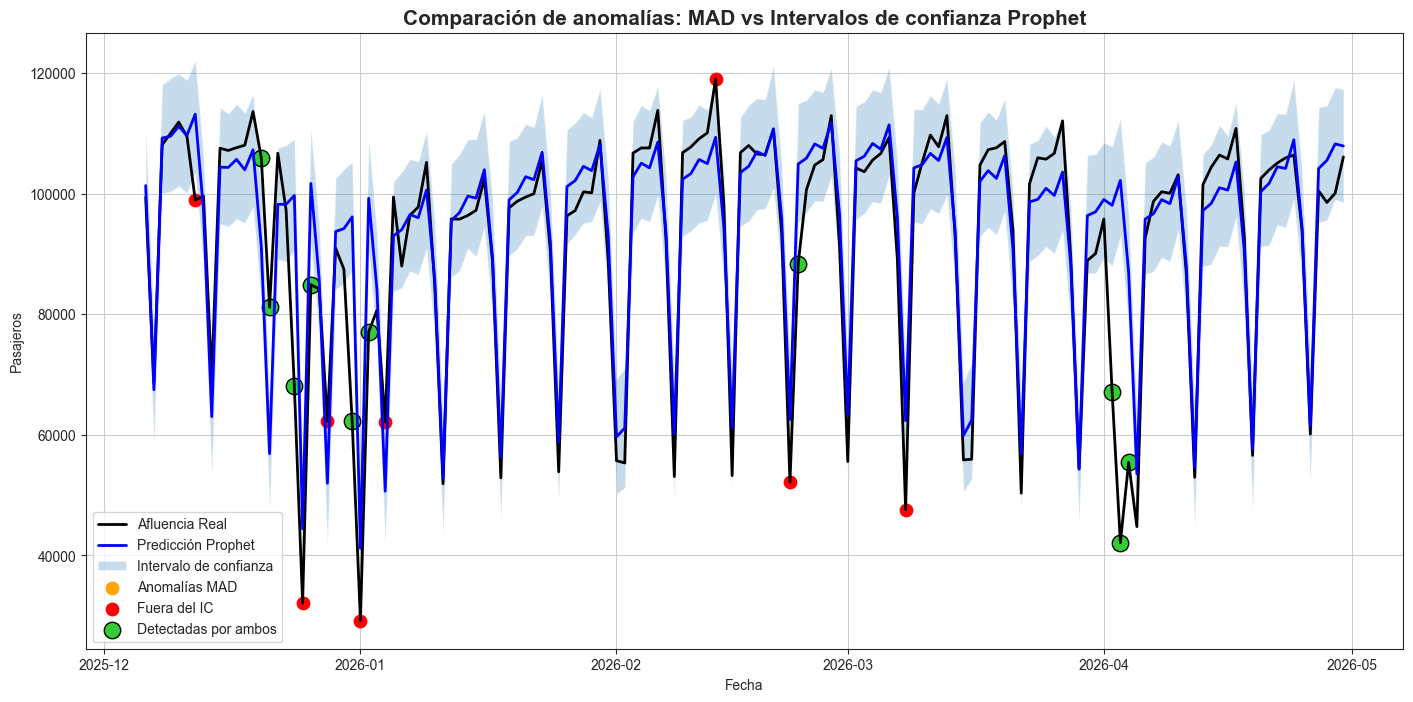


--- RESUMEN DE DETECCIÓN ---

Anomalías MAD: 10
Anomalías IC Prophet: 18
Coincidencias entre ambos: 10


In [ ]:
# ANOMALÍAS POR MAD EN RESIDUOS

test_prophet['anomalia_mad'] = (
    (test_prophet['residuo'] > limite_superior) |
    (test_prophet['residuo'] < limite_inferior))

test_prophet['anomalia_ic'] = (
    (test_prophet['y'] < test_prophet['yhat_lower']) |
    (test_prophet['y'] > test_prophet['yhat_upper']))

test_prophet['anomalia_ambos'] = (
    test_prophet['anomalia_mad'] &
    test_prophet['anomalia_ic'])

plt.figure(figsize=(17,8))
# Serie real
plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Afluencia Real',
    color='black',
    linewidth=2
)

# Predicción Prophet
plt.plot(
    test_prophet['ds'],
    test_prophet['yhat'],
    label='Predicción Prophet',
    color='blue',
    linewidth=2
)

plt.fill_between(
    test_prophet['ds'],
    test_prophet['yhat_lower'],
    test_prophet['yhat_upper'],
    alpha=0.25,
    label='Intervalo de confianza'
)

plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_mad'],
        'y'
    ],
    color='orange',
    s=80,
    label='Anomalías MAD'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ic'],
        'y'
    ],
    color='red',
    s=80,
    label='Fuera del IC'
)


plt.scatter(
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'ds'
    ],
    test_prophet.loc[
        test_prophet['anomalia_ambos'],
        'y'
    ],
    color='limegreen',
    edgecolors='black',
    s=140,
    label='Detectadas por ambos'
)

plt.title(
    'Comparación de anomalías: MAD vs Intervalos de confianza Prophet',
    fontsize=15,
    fontweight='bold'
)
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()


print("\n--- RESUMEN DE DETECCIÓN ---\n")
print(f"Anomalías MAD: {test_prophet['anomalia_mad'].sum()}")
print(f"Anomalías IC Prophet: {test_prophet['anomalia_ic'].sum()}")
print(f"Coincidencias entre ambos: {test_prophet['anomalia_ambos'].sum()}")

In [ ]:
import numpy as np
import pandas as pd

# 1. Se parte nuevamente del dataset limpio (agrupado por dia)
df_limpio = dataset_original_copy.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum().reset_index()
#copia de seguridad del dataset limpio
df_limpio_copy = dataset_original_copy.groupby(['fecha', 'linea', 'estacion'])['afluencia'].sum().reset_index()
# 2. Agrupamos logicamente para calculos moviles
agg = df_limpio.groupby(['linea', 'estacion'])['afluencia']

# 3. Calculo Media y Desviacion Estandar Movil (Ventana 7 dias, con shift para no ver el futuro)
df_limpio['media_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
df_limpio['std_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).std().shift(1))

# 4. Recalculo de Z-Score Clasico
df_limpio['zscore_movil'] = (df_limpio['afluencia'] - df_limpio['media_movil']) / df_limpio['std_movil']

# 5. Generamos la bandera booleana de anomalia (enfocada en caidas)
df_limpio['anomalia_z'] = df_limpio['zscore_movil'] < -3

# --- Calcular MAD ---
def rolling_mad(x):
    mediana = np.median(x)
    return np.median(np.abs(x - mediana))

df_limpio['mediana_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).median().shift(1))
df_limpio['mad_movil'] = agg.transform(lambda x: x.rolling(window=7, min_periods=1).apply(rolling_mad).shift(1))
df_limpio['zscore_robusto'] = (df_limpio['afluencia'] - df_limpio['mediana_movil']) / (df_limpio['mad_movil'] * 1.4826)


A continuación se procesan todas las estaciones, genera las predicciones de prophet y MAD creando una clasificación de las anomalías:

CRÍTICA (Consenso Absoluto)
¿Qué significa?: MAD detectó que hoy hubo un desplome severo de gente comparado con los últimos 7 días Y Prophet confirmó que ese desplome es matemáticamente imposible para esta época del año.
Interpretación Operativa: Es un Incidente Mayor casi seguro. Hubo un cierre de estación, un corte de energía prolongado o un tren descarrilado.

ALTA (Desviación Estacional)
¿Qué significa?: MAD dijo "todo normal" (la afluencia se parece a la de ayer), PERO Prophet detectó que los números están muy por debajo de lo que dicta la historia.
Interpretación Operativa: Es un Fallo Crónico o Degradación de Servicio. Por ejemplo: si una escalera eléctrica gigante lleva rota toda la semana, la gente empieza a evitar esa estación paulatinamente. MAD no lo nota porque la caída es lenta, pero Prophet sabe que ahí debería haber un 20% más de pasajeros.

MEDIA (Shock Local / Ruido)
¿Qué significa?: MAD detectó una caída brusca respecto a ayer, PERO Prophet dice que "es normal, siempre pasa en estas fechas".
Interpretación Operativa: Suele ser comportamiento natural de la ciudad. Por ejemplo, el jueves de Semana Santa. MAD ve que ayer miércoles estaba lleno y hoy vacío, por lo que entra en pánico. Prophet sabe que es festividad y desestima la alerta.

# **MODELO PARA LAS 195 SERIES DE TIEMPO**

In [ ]:
def motor_auditoria_consenso_mad_bidireccional(df_input):
    resultados_master = []
    grupos = df_input.groupby(['linea', 'estacion'])
    total = len(grupos)
    
    print(f"Iniciando auditoría masiva bidireccional para {total} estaciones...")

    for i, ((linea, estacion), df_grupo) in enumerate(grupos, 1):
        try:
            df_p = df_grupo.copy()
            if 'fecha' not in df_p.columns: df_p = df_p.reset_index()
            df_prophet = df_p[['fecha', 'afluencia']].rename(columns={'fecha': 'ds', 'afluencia': 'y'})

            # No se entrena con dias de afluencia=0 (cierres de estacion): sesgarian
            # la tendencia/estacionalidad hacia abajo. Se predice sobre TODOS los
            # dias (incluidos los ceros) para que un cierre real siga detectandose
            # como anomalia al comparar contra lo que Prophet esperaba.
            df_prophet_train = df_prophet[df_prophet['y'] > 0]

            m = Prophet(yearly_seasonality=True, weekly_seasonality=True, changepoint_prior_scale=0.03)
            m.add_country_holidays(country_name='MX')
            m.fit(df_prophet_train)
            
            forecast = m.predict(df_prophet[['ds']])
            
            df_merge = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
                df_p[['fecha', 'afluencia', 'zscore_robusto']], 
                left_on='ds', right_on='fecha'
            )
            
            # --- Detección en ambas direcciones (Alza y Baja) ---
            df_merge['det_prophet'] = (df_merge['afluencia'] < df_merge['yhat_lower']) | (df_merge['afluencia'] > df_merge['yhat_upper'])
            df_merge['det_mad'] = (df_merge['zscore_robusto'] < -3) | (df_merge['zscore_robusto'] > 3)
            
            # Reglas de Consenso
            conditions = [
                (df_merge['det_prophet'] & df_merge['det_mad']), 
                (df_merge['det_prophet'] & ~df_merge['det_mad']),
                (~df_merge['det_prophet'] & df_merge['det_mad']) 
            ]
            prioridades = ['CRÍTICA (Consenso)', 'ALTA (Solo Prophet)', 'MEDIA (Solo MAD)']
            df_merge['prioridad_auditoria'] = np.select(conditions, prioridades, default='Normal')
            
            df_merge['linea'] = linea
            df_merge['estacion'] = estacion
            df_merge['impacto_pasajeros'] = round(df_merge['afluencia'] - df_merge['yhat'], 0)
            
            # --- Etiquetado de la dirección de la anomalía ---
            df_merge['direccion_anomalia'] = np.where(df_merge['impacto_pasajeros'] > 0, 'Alza (Pico atípico)', 'Baja (Caída atípica)')
            
            # Guardar solo anomalías
            anomalias = df_merge[df_merge['prioridad_auditoria'] != 'Normal'].copy()
            resultados_master.append(anomalias)
            
            if i % 10 == 0: print(f"Progreso: {i}/{total} estaciones procesadas.")
            
        except Exception as e:
            print(f"Error en {estacion} ({linea}): {e}")
            continue

    df_final = pd.concat(resultados_master, ignore_index=True)
    return df_final

# Ejecución
master_auditoria = motor_auditoria_consenso_mad_bidireccional(df_limpio)

master_auditoria.to_csv('master_auditoria_consenso_MAD.csv', index=False)
master_auditoria.to_excel('master_auditoria_consenso_MAD.xlsx', index=False)

# RESULTADOS: PROPHET + Z-SCORE ROBUSTO

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/868587453.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




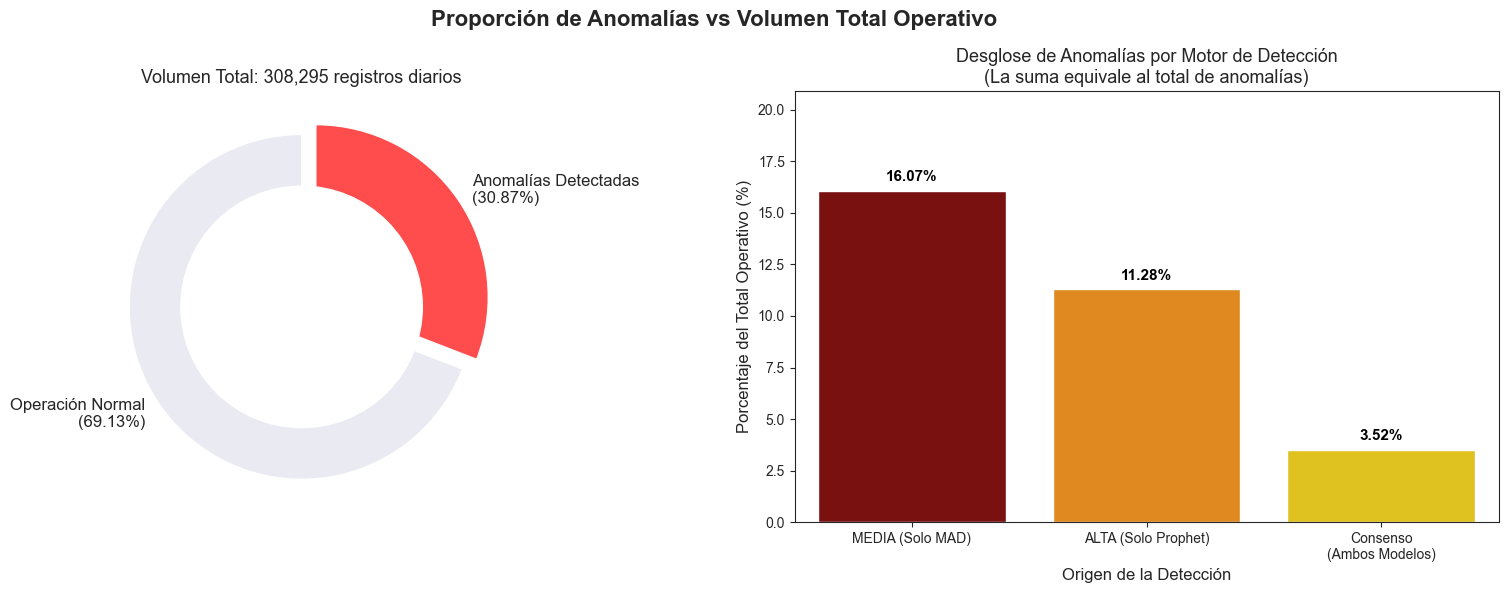

In [ ]:
def graficar_balance_anomalias(df_total, df_anomalias):
    # ---------------------------------------------------------
    # Evitar el doble conteo
    # un mismo evento (fecha-línea-estacion) no sume dos veces
    # ---------------------------------------------------------
    df_anomalias_unicas = df_anomalias.drop_duplicates(subset=['fecha', 'linea', 'estacion']).copy()
    
    # 1. Cálculos de proporciones exactas
    total_registros = len(df_total)
    total_anomalos = len(df_anomalias_unicas)
    total_normales = total_registros - total_anomalos
    
    pct_normal = (total_normales / total_registros) * 100
    pct_anomalo = (total_anomalos / total_registros) * 100
    
    # Desglose de prioridades respecto al TOTAL de los datos
    conteo_prioridad = df_anomalias_unicas['prioridad_auditoria'].value_counts()
    
    # Renombrar índices para evidenciar que son mutuamente excluyentes

    mapeo_nombres = {
        'CRÍTICA (Consenso)': 'Consenso\n(Ambos Modelos)',
        'ALTA (Prophet)': 'Exclusivo\n(Solo Prophet)',
        'MEDIA (Z-Score)': 'Exclusivo\n(Solo MAD)'
    }
    conteo_prioridad.index = conteo_prioridad.index.map(lambda x: mapeo_nombres.get(x, x))
    
    pct_prioridades = (conteo_prioridad / total_registros) * 100
    
    # 2. Configuración del panel visual
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Proporción de Anomalías vs Volumen Total Operativo', fontsize=16, fontweight='bold')
    
    # --- El panorama general (Donut Chart) ---
    labels_macro = [f'Operación Normal\n({pct_normal:.2f}%)', f'Anomalías Detectadas\n({pct_anomalo:.2f}%)']
    sizes_macro = [total_normales, total_anomalos]
    colors_macro = ['#EAEAF2', '#FF4C4C']
    explode = (0, 0.1)  # Destacar las anomalías
    
    ax1.pie(sizes_macro, explode=explode, labels=labels_macro, colors=colors_macro, 
            autopct='', shadow=False, startangle=90, textprops={'fontsize': 12})
    
    # Convertir a gráfica de dona
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax1.add_patch(centre_circle)
    ax1.set_title(f'Volumen Total: {total_registros:,} registros diarios', fontsize=13)
    
    # --- Desglose de Criticidad (Bar Chart) ---
    sns.barplot(x=pct_prioridades.index, y=pct_prioridades.values, ax=ax2, 
                palette=['#8B0000', '#FF8C00', '#FFD700'])
    
    ax2.set_title('Desglose de Anomalías por Motor de Detección\n(La suma equivale al total de anomalías)', fontsize=13)
    ax2.set_ylabel('Porcentaje del Total Operativo (%)', fontsize=12)
    ax2.set_xlabel('Origen de la Detección', fontsize=12)
    
    # etiquetas de datos sobre las barras
    for p in ax2.patches:
        ax2.annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                     textcoords='offset points')
        
    # eje Y para porcentajes pequeños
    ax2.set_ylim(0, max(pct_prioridades.values) * 1.3)
    
    plt.tight_layout()
    plt.show()

# Ejecución de la gráfica 
graficar_balance_anomalias(df_limpio_copy, master_auditoria)

Código para obtención de la muestra calculada necesaria para un 95% de confianza y un 5% de margen de error:
$$n = \frac{N \cdot Z^2 \cdot p \cdot (1-p)}{(N-1) \cdot e^2 + Z^2 \cdot p \cdot (1-p)}$$
Donde:

$N$ = Tamaño de la población ($11,117$)

$Z$ = Nivel de confianza del 95% ($1.96$)

$e$ = Margen de error del 5% ($0.05$)$p$ = Probabilidad de ocurrencia ($0.5$, para maximizar el tamaño de muestra y ser conservadores)

Si sustituimos los valores:

$$n = \frac{11117 \cdot (1.96)^2 \cdot 0.5 \cdot 0.5}{(11116) \cdot (0.05)^2 + (1.96)^2 \cdot 0.5 \cdot 0.5} \approx 372$$

Técnica: Muestreo Estratificado Proporcional

Esta técnica divide los registros de anomalías críticas (donde prophet y MAD covergen) en "estratos" (subgrupos lógicos) y toma una muestra proporcional al peso de cada grupo. Si la Línea 1 tiene el 20% de las anomalías totales, la técnica se asegurará de que el 20% de tu muestra de 372 registros pertenezca exactamente a la Línea 1.

Los estratos más lógicos para nuestros datos son "Línea" y "Dirección" de la anomalía (Alza/Baja).

El siguiente código tiene como finalidad confirmar la replicabilidad de la extracción de la muestra, aunque la muestra utilizada para el resto del proyecto se extrajo del mismo algoritmo, fue una muestra unica extraida el 24 de abril del 2026

In [ ]:
# 1. Filtrado de solo anomalías Críticas
df_criticas = master_auditoria[master_auditoria['prioridad_auditoria'] == 'CRÍTICA (Consenso)'].copy()
df_criticas.columns = df_criticas.columns.str.strip().str.lower()

#  la fila 1 siempre sera la misma en cualquier computadora
df_criticas = df_criticas.sort_values(by=['fecha', 'linea', 'estacion']).reset_index(drop=True)
# ---------------------------------------------------------

# 2. Definimos el tamaño de muestra que nos dio la fórmula estadística
tamaño_muestra = 372

# 3. Calculo de la fracción (el porcentaje de los 11,117 registros)
fraccion = tamaño_muestra / len(df_criticas)

# 4. Muestreo Estratificado Proporcional por Línea y Dirección de Anomalía
muestra_auditoria = df_criticas.groupby(
    ['linea', 'direccion_anomalia'], 
    group_keys=False
).sample(frac=fraccion, random_state=42)

# 5. CSV para la investigación manual
muestra_auditoria.to_csv('muestra_estratificada_auditoria_manual.csv', index=False)
muestra_auditoria.to_excel('muestra_estratificada_auditoria_manual.xlsx', index=False)

print(f"Población total de anomalías críticas: {len(df_criticas)}")
print(f"Tamaño de la muestra extraída: {len(muestra_auditoria)}")
print("Columnas preservadas exitosamente:", muestra_auditoria.columns.tolist())

Población total de anomalías críticas: 11134
Tamaño de la muestra extraída: 373
Columnas preservadas exitosamente: ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'fecha', 'afluencia', 'zscore_robusto', 'det_prophet', 'det_mad', 'prioridad_auditoria', 'linea', 'estacion', 'impacto_pasajeros', 'direccion_anomalia']


El siguiente código de comparativa muestra los gráficos de comparación del comportamiento del total de anomalías detectadas por nuestro modelo contra el comportamiento de la muestra replicable


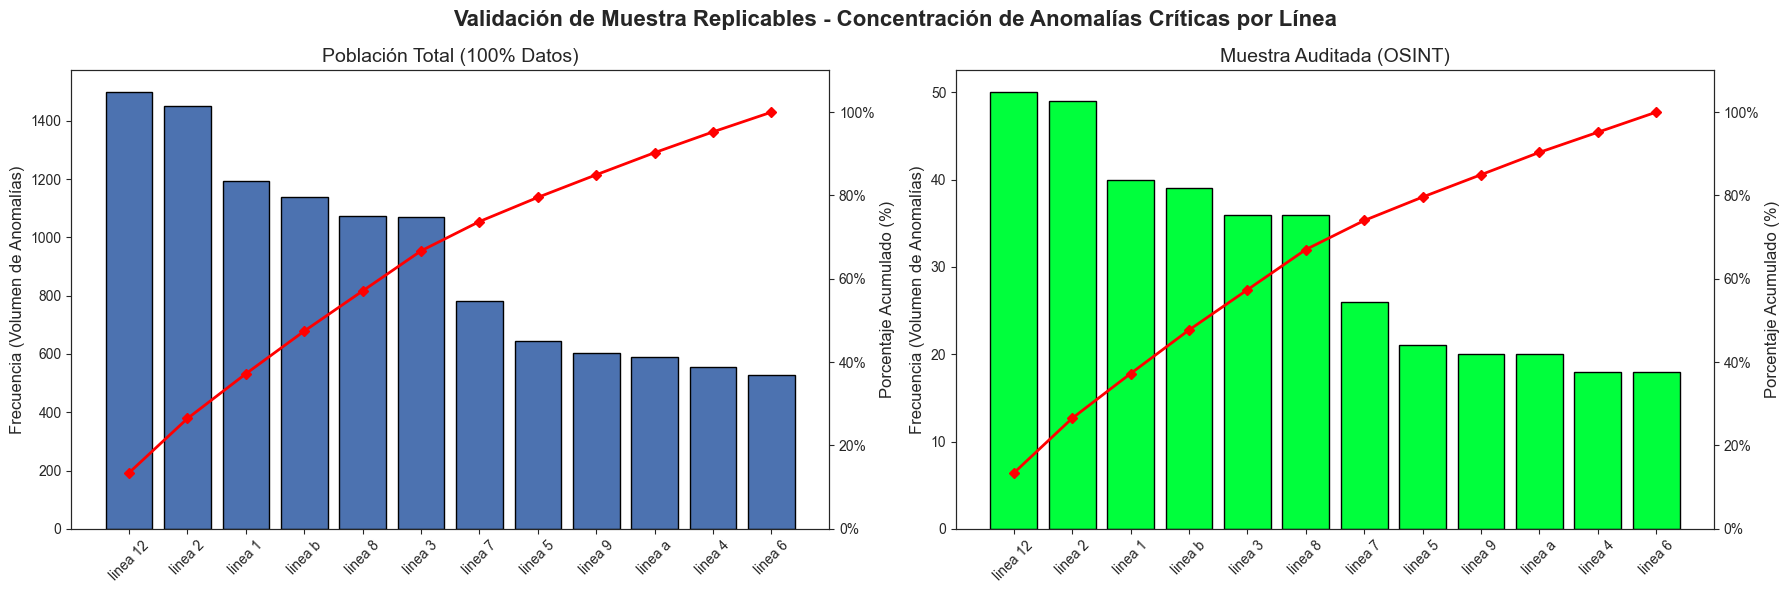

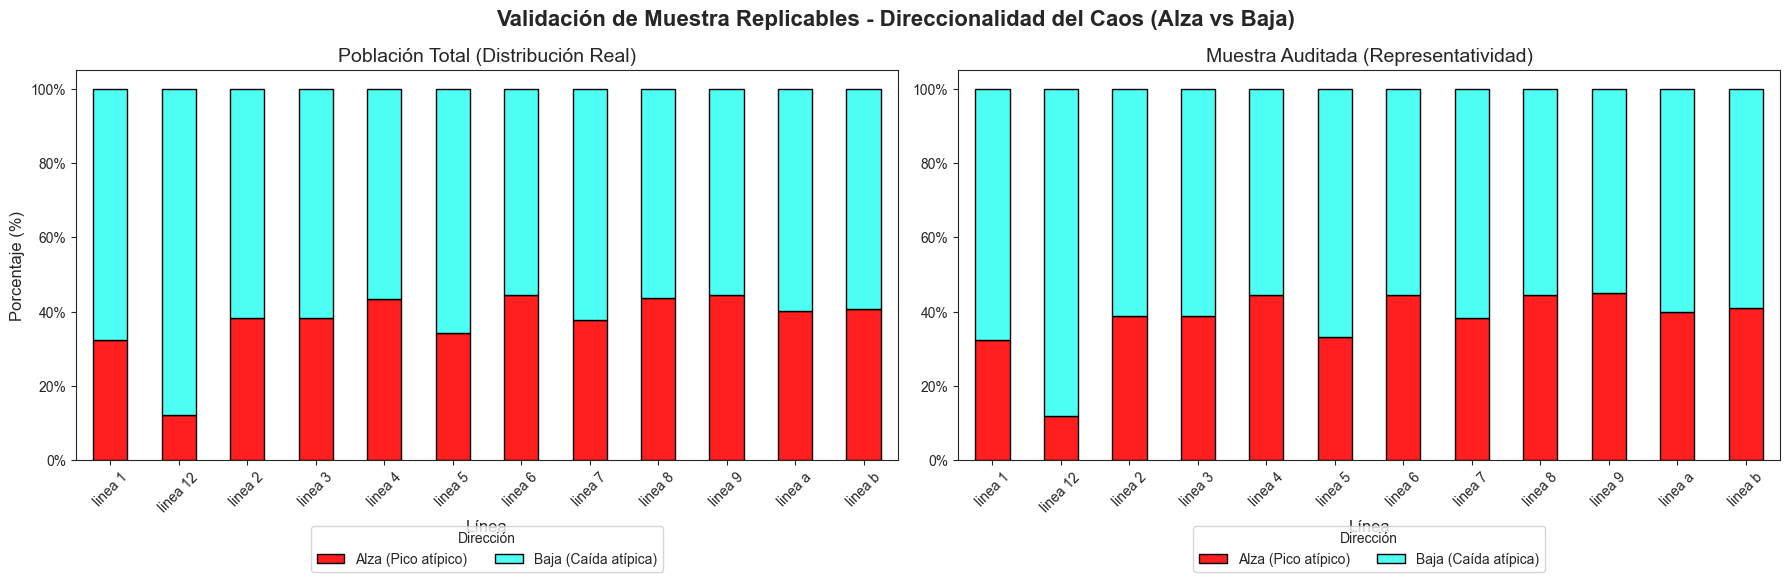

In [ ]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo de la población total de anomalías
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_csv('muestra_estratificada_auditoria_manual.csv')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.strip().str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.strip().str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#00FF3C")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra Replicables - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1F1F", "#4DFFF3"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

A continuación se presentan las mismas gráficas de comparación de comportamiento pero para la muestra única obtenida el dia 24 de abril del 2026 que fue con la que se estuvo trabajando

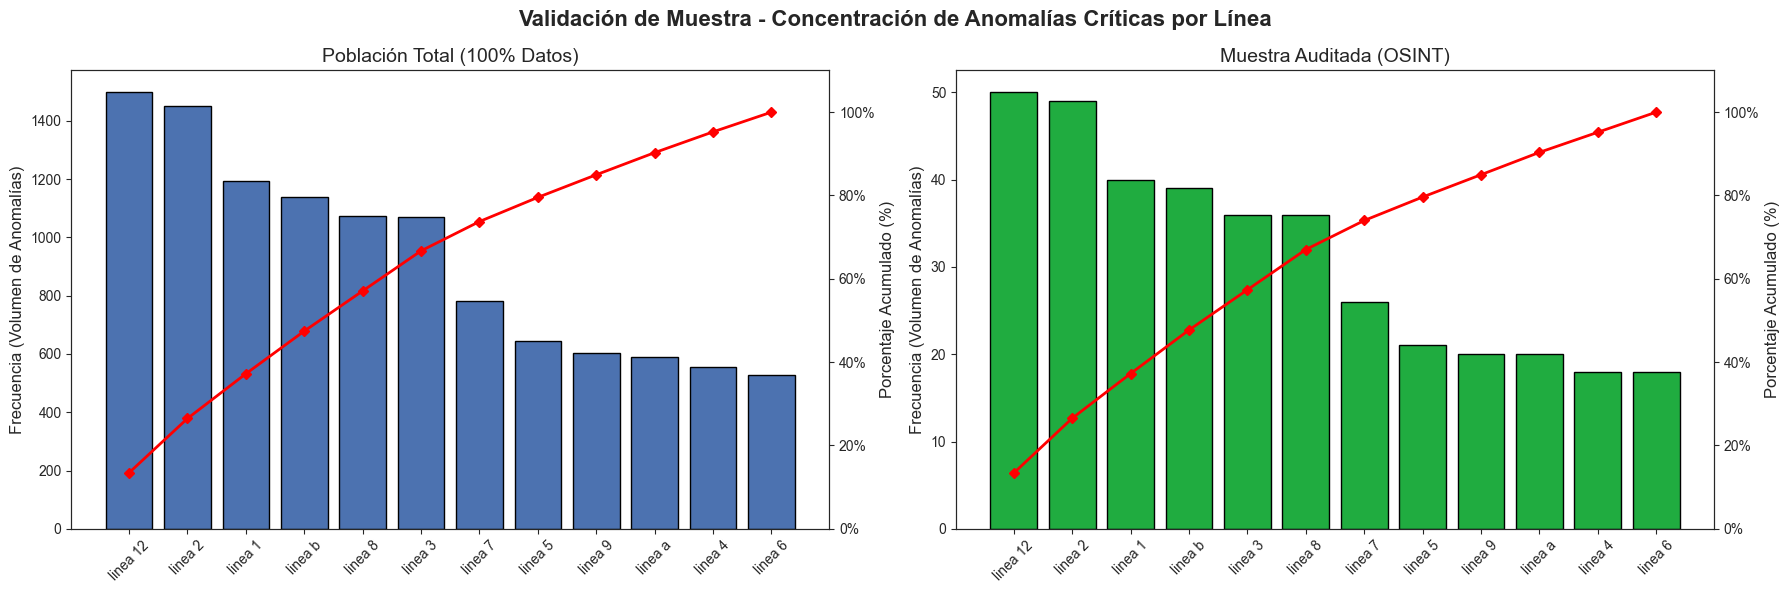

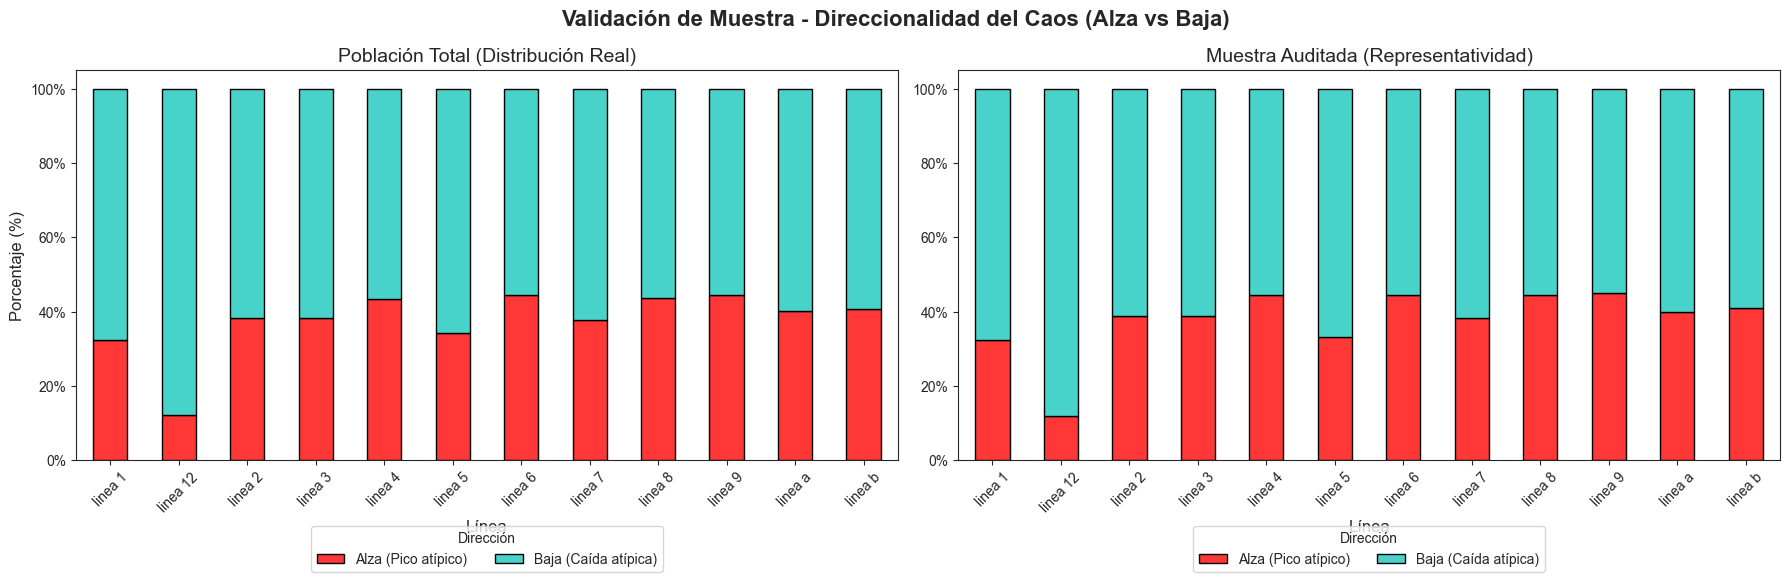

In [ ]:
# 0. CARGA Y PREPARACIÓN DE DATOS
# Cargar el archivo maestro (Población Total)
df_poblacion = pd.read_csv('master_auditoria_consenso_MAD.csv') 
# Filtrar solo las anomalías críticas de la población total
df_pob_critica = df_poblacion[df_poblacion['prioridad_auditoria'].str.contains('CRÍTICA', na=False)].copy()

# Cargar el archivo de la muestra auditada manualmente
df_muestra = pd.read_excel('muestra_estratificada_auditoria_manual.xlsx')

# Normalizar los nombres de columnas para que coincidan (minúsculas)
df_muestra.columns = df_muestra.columns.str.lower()
df_pob_critica.columns = df_pob_critica.columns.str.lower()

# DIAGRAMA DE PARETO DUAL (Concentración por Línea)
def calcular_pareto(df, columna):
    """Calcula frecuencias y porcentaje acumulado para Pareto"""
    conteo = df[columna].value_counts().reset_index()
    conteo.columns = [columna, 'frecuencia']
    conteo['pct'] = (conteo['frecuencia'] / conteo['frecuencia'].sum()) * 100
    conteo['acumulado'] = conteo['pct'].cumsum()
    return conteo

pareto_pob = calcular_pareto(df_pob_critica, 'linea')
pareto_muestra = calcular_pareto(df_muestra, 'linea')

# Crear figura para Pareto Dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Concentración de Anomalías Críticas por Línea', fontsize=16, fontweight='bold')

# Función para graficar un Pareto
def plot_pareto(ax, data, title, color_bar):
    ax.bar(data['linea'], data['frecuencia'], color=color_bar, edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Frecuencia (Volumen de Anomalías)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    # Eje secundario para el porcentaje acumulado
    ax_pct = ax.twinx()
    ax_pct.plot(data['linea'], data['acumulado'], color='red', marker='D', ms=5, linewidth=2)
    ax_pct.yaxis.set_major_formatter(PercentFormatter())
    ax_pct.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)
    ax_pct.set_ylim(0, 110)

plot_pareto(ax1, pareto_pob, f'Población Total (100% Datos)', '#4C72B0')
plot_pareto(ax2, pareto_muestra, f'Muestra Auditada (OSINT)', "#20AC40")

plt.tight_layout()
plt.show()

# BALANCE DE DIRECCIONALIDAD (Alza vs Baja al 100%)
def preparar_direccionalidad(df):
    """Crea una tabla cruzada normalizada al 100% de línea vs dirección"""
    ct = pd.crosstab(df['linea'], df['direccion_anomalia'], normalize='index') * 100
    # Asegurar que las líneas estén en el mismo orden (alfabético/numérico)
    return ct.sort_index()

dir_pob = preparar_direccionalidad(df_pob_critica)
dir_muestra = preparar_direccionalidad(df_muestra)

# Crear figura para Direccionalidad Dual
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Validación de Muestra - Direccionalidad del Caos (Alza vs Baja)', fontsize=16, fontweight='bold')

colores_dir = ["#FF1D1DE2", "#48D3CA"] # Rojo suave para Baja, Verde agua para Alza

dir_pob.plot(kind='bar', stacked=True, ax=ax3, color=colores_dir, edgecolor='black')
ax3.set_title('Población Total (Distribución Real)', fontsize=14)
ax3.set_ylabel('Porcentaje (%)', fontsize=12)
ax3.set_xlabel('Línea', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter())
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

dir_muestra.plot(kind='bar', stacked=True, ax=ax4, color=colores_dir, edgecolor='black')
ax4.set_title('Muestra Auditada (Representatividad)', fontsize=14)
ax4.set_xlabel('Línea', fontsize=12)
ax4.yaxis.set_major_formatter(PercentFormatter())
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Dirección', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

/var/folders/_b/8cx6gyf553j_qz7kvr2vf9280000gn/T/ipykernel_28070/2952930612.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/Users/juanmendiola/.pyenv/versions/3.11.9/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



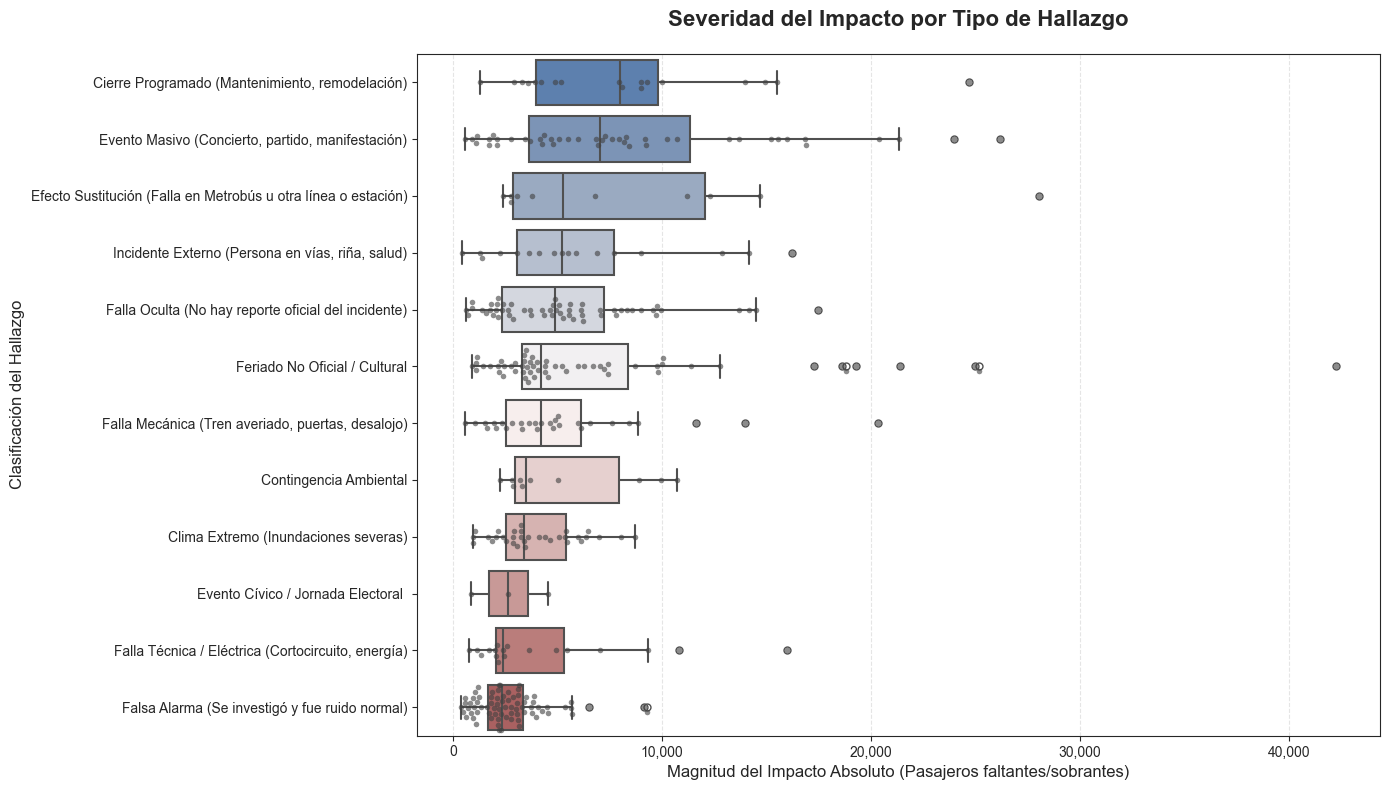

In [ ]:
# 0. CARGA DE DATOS DE LA BITÁCORA MANUAL
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# Asegurar que los nombres de columnas coincidan
df_muestra.columns = df_muestra.columns.str.lower()
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Clasificación de causas encontradas en la investigación manual
conteo_causas = df_muestra['hallazgo'].value_counts().reset_index()
conteo_causas.columns = ['Causa', 'Frecuencia']
conteo_causas = conteo_causas.sort_values('Frecuencia', ascending=True)

total_anomalias = conteo_causas['Frecuencia'].sum()
conteo_causas['Porcentaje'] = (conteo_causas['Frecuencia'] / total_anomalias) * 100

#etiqueta de texto
conteo_causas['Texto_Etiqueta'] = conteo_causas.apply(
    lambda row: f"{int(row['Frecuencia'])} ({row['Porcentaje']:.1f}%)", axis=1
)

# calculo el valor máximo para extender el eje X
max_frecuencia = conteo_causas['Frecuencia'].max()

# Gráfico interactivo con paleta de colores cualitativa
fig_barras = px.bar(
    conteo_causas, 
    x='Frecuencia', 
    y='Causa', 
    orientation='h',
    text='Texto_Etiqueta',
    color='Causa', 
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='<b>Clasificación de Causas (Investigación OSINT)</b>',
    labels={'Frecuencia': 'Número de Incidentes Críticos', 'Causa': 'Clasificación del Hallazgo'}
)

fig_barras.update_traces(
    textposition='outside', 
    textfont=dict(size=10, color='#333333'),
    cliponaxis=False  #  Evita que el eje corte el texto
)

fig_barras.update_layout(
    template='plotly_white', 
    height=500,
    showlegend=False, 
    xaxis=dict(
        showgrid=True, 
        gridcolor='#E5E5E5',
        range=[0, max_frecuencia * 1.2] # Expande el eje X un 20% más allá de la barra más grande
    ),
    yaxis=dict(showgrid=False),
    margin=dict(r=150) # Aumenta el margen derecho de la imagen (de 90 a 150)
)

fig_barras.show()


# ANÁLISIS DE SEVERIDAD 
plt.figure(figsize=(14, 8))
plt.title('Severidad del Impacto por Tipo de Hallazgo', fontsize=16, fontweight='bold', pad=20)

# Convertir impacto a absoluto
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Ordenar las cajas
orden_cajas = df_muestra.groupby('hallazgo')['impacto_absoluto'].median().sort_values(ascending=False).index


sns.boxplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    palette='vlag',
    linewidth=1.5,
    fliersize=5
)

# Los puntos de distribución real
sns.swarmplot(
    data=df_muestra, 
    y='hallazgo', 
    x='impacto_absoluto', 
    order=orden_cajas,
    color='.25',
    alpha=0.6,
    size=4
)

plt.xlabel('Magnitud del Impacto Absoluto (Pasajeros faltantes/sobrantes)', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Formatear eje X
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

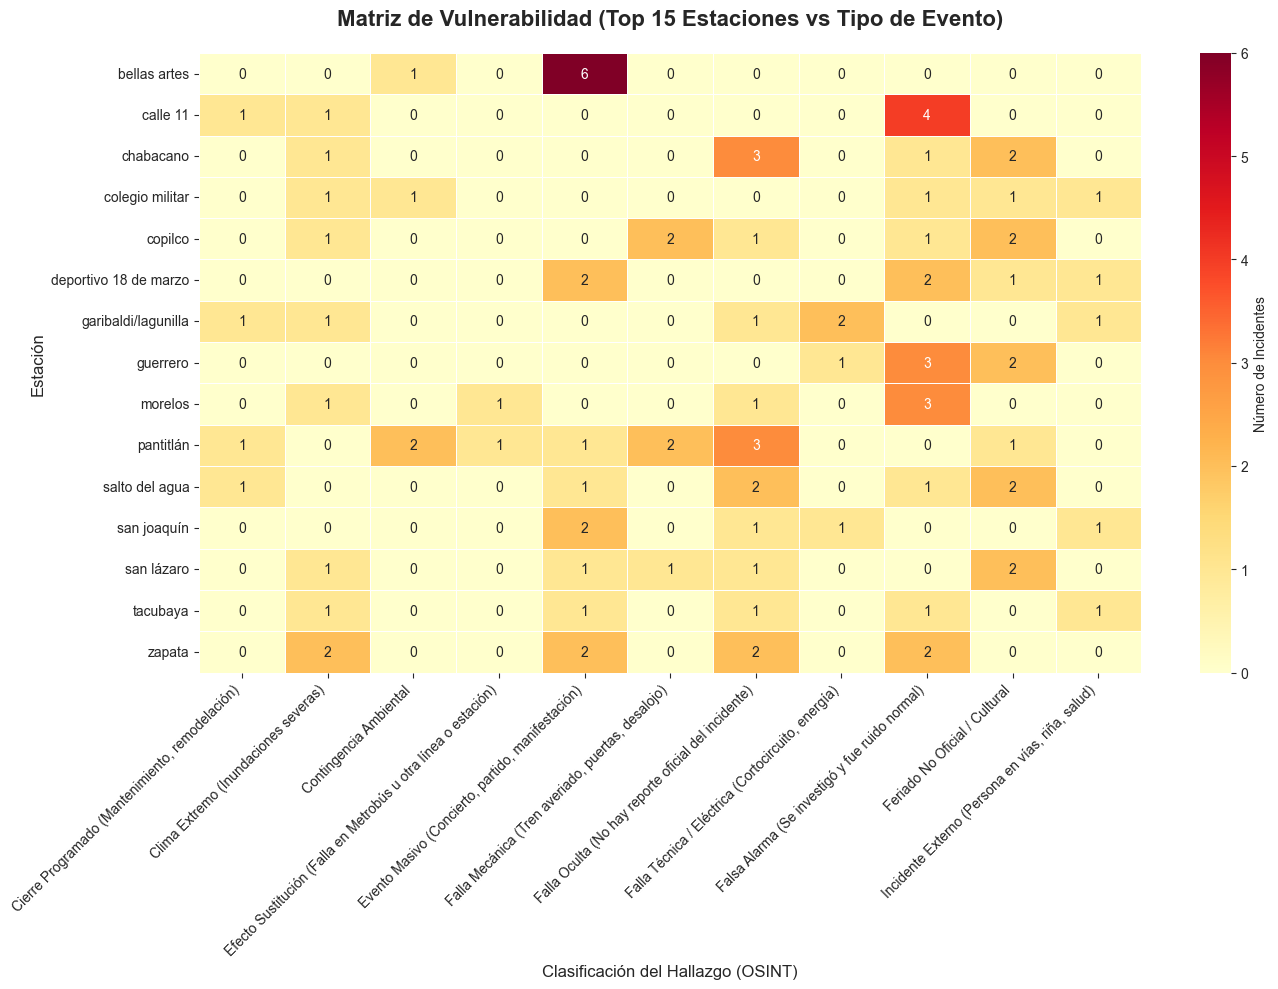


 TOP 5 CASOS CRÍTICOS

Caso de Estudio #1 | Impacto: 42,277 pasajeros (Alza (Pico atípico))
Fecha: 2022-01-02 0:00:00 | Línea: linea 8 | Estación: constitución de 1917
Causa Detectada: Feriado No Oficial / Cultural
Descripción: Afluencia a la alza dado eventos de temporada de inicio de año e inicio de recuperación de periodo postpandemia
Evidencia: Sin fuente URL

Caso de Estudio #2 | Impacto: -28,037 pasajeros (Baja (Caída atípica))
Fecha: 2024-03-29 0:00:00 | Línea: linea b | Estación: buenavista
Causa Detectada: Efecto Sustitución (Falla en Metrobús u otra línea o estación)
Descripción: Buenavista, los usuarios reportan tiempos de espera de 10 minutos en la estación San Lázaro (que conecta con el Metrobús).
Evidencia: https://www.milenio.com/politica/comunidad/metro-metrobus-cdmx-hoy-29-marzo-2024-ultimas-noticias-en-vivo-atm

Caso de Estudio #3 | Impacto: -26,188 pasajeros (Baja (Caída atípica))
Fecha: 2025-11-25 0:00:00 | Línea: linea 2 | Estación: pino suárez
Causa Detectada: Ev

In [ ]:
# 0. CARGA DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')

# los nombres de columnas estan estandarizados (minúsculas para el código)
df_muestra.columns = df_muestra.columns.str.lower()
# La columna se llama 'hallazgo_principal', se renombra a 'hallazgo' por simplicidad
if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# MATRIZ DE VULNERABILIDAD (Heatmap)
# se toman solo el TOP 15 de estaciones más afectadas
top_estaciones = df_muestra['estacion'].value_counts().head(15).index

# Filtrado del dataframe solo con esas estaciones
df_top_est = df_muestra[df_muestra['estacion'].isin(top_estaciones)]

# Creamos una tabla cruzada entre Estación y Hallazgo
matriz_vuln = pd.crosstab(df_top_est['estacion'], df_top_est['hallazgo'])

plt.figure(figsize=(14, 10))
plt.title('Matriz de Vulnerabilidad (Top 15 Estaciones vs Tipo de Evento)', fontsize=16, fontweight='bold', pad=20)

# Generamos el Mapa de Calor
sns.heatmap(
    matriz_vuln, 
    annot=True,          # Muestra el número dentro del cuadro
    fmt='d',             # Formato entero
    cmap='YlOrRd',       # Paleta de colores: Amarillo -> Naranja -> Rojo (Alerta)
    linewidths=.5,       # Líneas de separación
    cbar_kws={'label': 'Número de Incidentes'}
)

plt.xlabel('Clasificación del Hallazgo (OSINT)', fontsize=12)
plt.ylabel('Estación', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# EXTRACCIÓN DE CASOS CRÍTICOS
print("\n" + "="*60)
print(" TOP 5 CASOS CRÍTICOS")
print("="*60)

# Calculo del impacto absoluto para encontrar los eventos más violentos
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# Orden de mayor a menor impacto y obtención de los 5 principales
top_casos = df_muestra.sort_values('impacto_absoluto', ascending=False).head(5)

# Iteración sobre los 5 casos para imprimirlos con formato de "Ficha Técnica"
for i, (_, row) in enumerate(top_casos.iterrows(), 1):
    print(f"\nCaso de Estudio #{i} | Impacto: {row['impacto']:,.0f} pasajeros ({row['direccion_anomalia']})")
    print(f"Fecha: {row['fecha']} | Línea: {row['linea']} | Estación: {row['estacion']}")
    print(f"Causa Detectada: {row['hallazgo']}")
    
    # Manejar el caso de que la descripción esté vacía
    desc = row.get('descripcion_incidente', 'Sin descripción detallada')
    if pd.isna(desc): desc = 'Sin descripción detallada'
    
    print(f"Descripción: {desc}")
    
    fuente = row.get('link_fuente_1', 'Sin fuente URL')
    if pd.isna(fuente): fuente = 'Sin fuente URL'
    print(f"Evidencia: {fuente}")

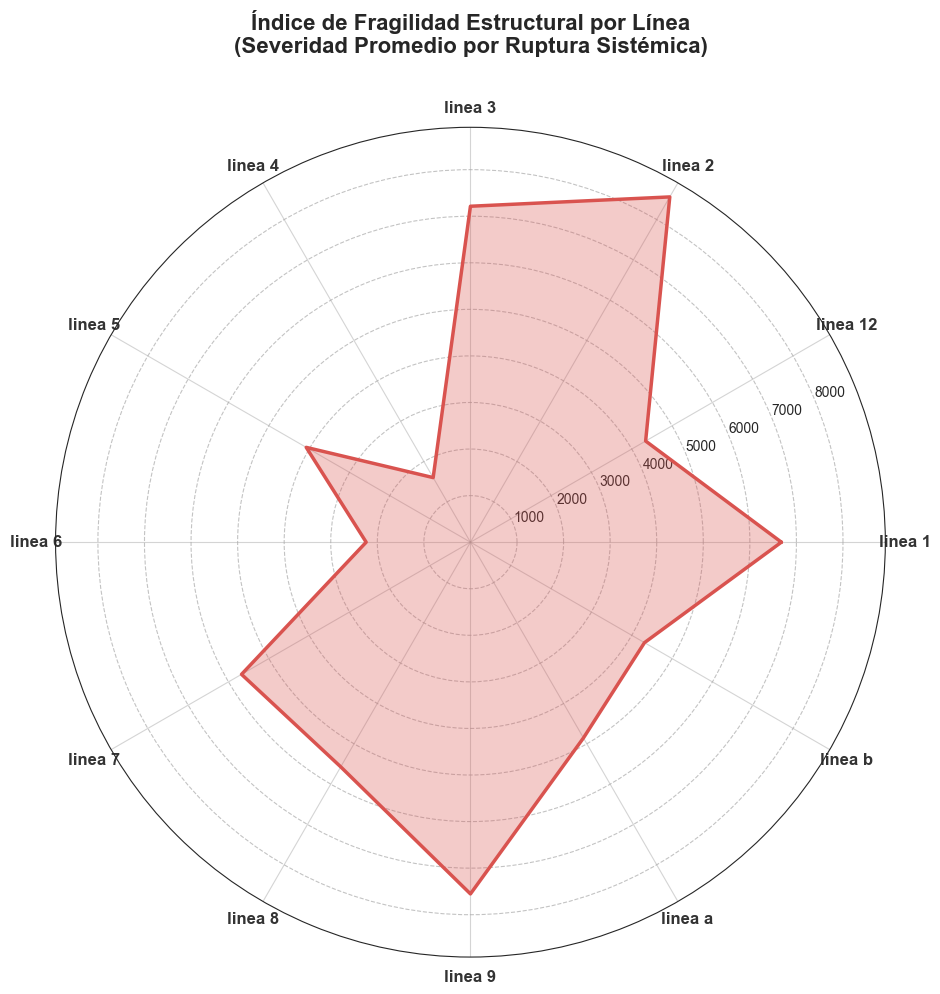

In [ ]:
# 0. CARGA Y PREPARACIÓN DE DATOS
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

# Uso del impacto absoluto para medir el "shock" sin importar si es alza o baja
df_muestra['impacto_absoluto'] = df_muestra['impacto'].abs()

# CÁLCULO DEL ÍNDICE DE FRAGILIDAD / RESILIENCIA
# Agrupación por línea y cálculo del Promedio de Impacto por evento
resiliencia = df_muestra.groupby('linea')['impacto_absoluto'].mean().reset_index()

# Ordenar las líneas alfabéticamente para que el radar tenga un orden lógico
resiliencia = resiliencia.sort_values('linea')

# Preparar listas de datos para el Radar Chart
categorias = resiliencia['linea'].tolist()
valores = resiliencia['impacto_absoluto'].tolist()

# El gráfico de radar necesita que el último valor 
# sea igual al primero para que el polígono "cierre" visualmente.
valores += valores[:1]

# Calcular los ángulos de la circunferencia para cada categoría (Línea)
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

# DIBUJAR EL GRÁFICO DE RADAR
# Iniciar figura especificando que es una proyección polar
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Dibujar el contorno del polígono
ax.plot(angulos, valores, color='#D9534F', linewidth=2.5, linestyle='solid', label='Impacto Promedio (Fragilidad)')

# Rellenar el área interior
ax.fill(angulos, valores, color='#D9534F', alpha=0.3)

# Configurar las etiquetas de las Líneas en el borde del círculo
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=12, fontweight='bold', color='#333333')

ax.yaxis.grid(True, color='#AAAAAA', linestyle='--', alpha=0.7)
ax.xaxis.grid(True, color='#AAAAAA', linestyle='-', alpha=0.5)

# Título del gráfico
plt.title('Índice de Fragilidad Estructural por Línea\n(Severidad Promedio por Ruptura Sistémica)', 
          size=16, fontweight='bold', y=1.08)

plt.tight_layout()
plt.show()

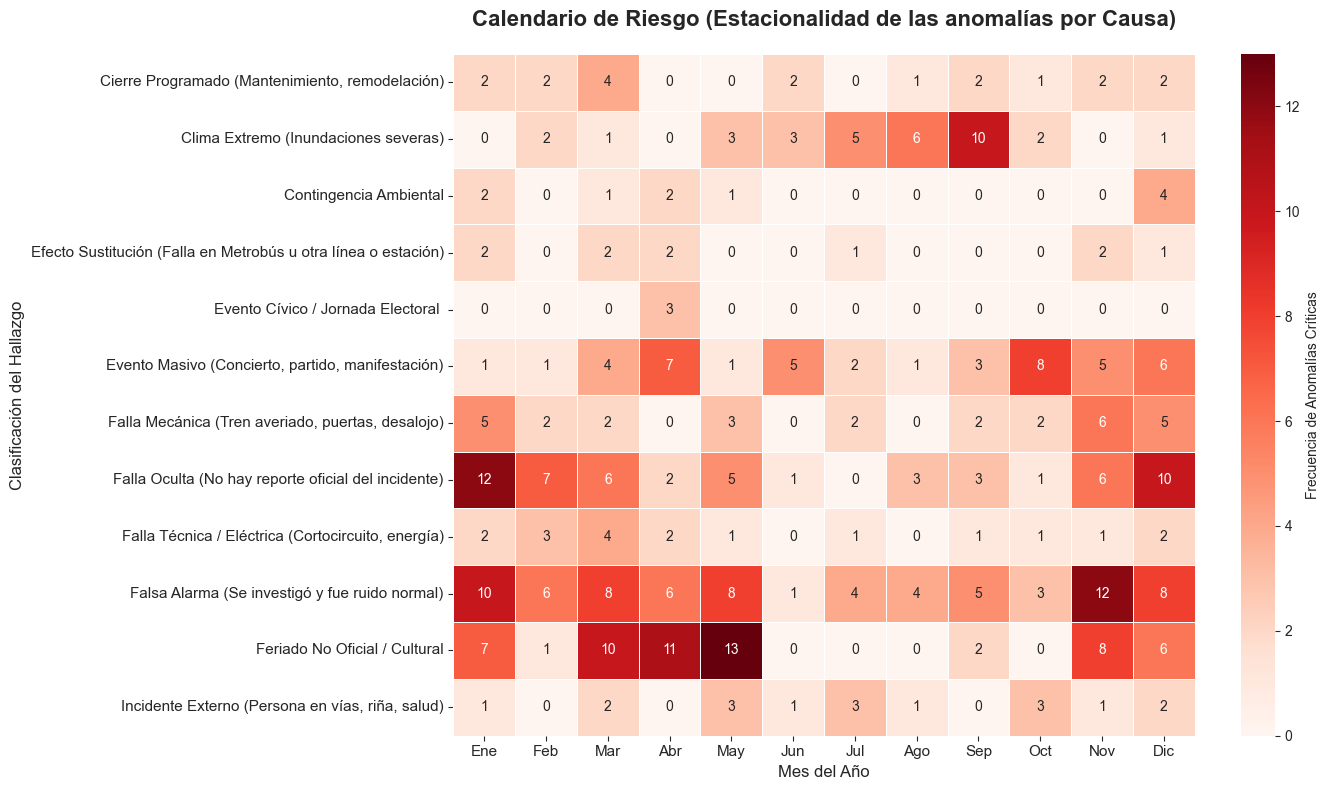

In [ ]:
# 1. Cargar la bitácora oficial de investigación manual
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv') # O bitacora_oficial_reparada.csv
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})

# 2. Extraer el mes de la fecha
# Converción de la columna a tipo datetime
df_muestra['fecha'] = pd.to_datetime(df_muestra['fecha'])

# número del mes (1 al 12)
df_muestra['mes_num'] = df_muestra['fecha'].dt.month

# converción de los números a nombres de meses en español para la gráfica
meses_esp = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_muestra['mes'] = df_muestra['mes_num'].map(meses_esp)

# 3. Crear la Matriz Temporal
heatmap_data = pd.crosstab(df_muestra['hallazgo'], df_muestra['mes'])

# Reorden de las columnas para que no salgan alfabéticamente, sino en orden de calendario
meses_presentes = [m for m in meses_esp.values() if m in heatmap_data.columns]
heatmap_data = heatmap_data[meses_presentes]

# 4. Graficar el Heatmap
plt.figure(figsize=(14, 8))
plt.title('Calendario de Riesgo (Estacionalidad de las anomalías por Causa)', fontsize=16, fontweight='bold', pad=20)

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt='d', 
    cmap='Reds', # Paleta de alerta
    linewidths=.5,
    cbar_kws={'label': 'Frecuencia de Anomalías Críticas'}
)

plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Clasificación del Hallazgo', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Preparación de los datos
df_muestra = pd.read_csv('bitacora_investigacion_anomalias_criticas.csv')
df_muestra.columns = df_muestra.columns.str.lower()

if 'hallazgo_principal' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'hallazgo_principal': 'hallazgo'})
if 'impacto_pasajeros' in df_muestra.columns:
    df_muestra = df_muestra.rename(columns={'impacto_pasajeros': 'impacto'})

df_muestra['impacto_abs'] = df_muestra['impacto'].abs()
impacto_causas = df_muestra.groupby('hallazgo')['impacto_abs'].sum().reset_index()

# Filtro flexible con .str.contains()
total_detectado = impacto_causas['impacto_abs'].sum()

# Busca cualquier fila que contenga las palabras "Falla Oculta"
mascara_oculta = impacto_causas['hallazgo'].str.contains('Falla Oculta', case=False, na=False)

# Separación correcta entre causas explicadas y la falla oculta, asegurando que la suma de la falla oculta se mantenga como un bloque independiente
explicadas = impacto_causas[~mascara_oculta].sort_values('impacto_abs', ascending=False)
falla_oculta_valor = impacto_causas[mascara_oculta]['impacto_abs'].sum()

# Construcción de la estructura de la Cascada
etiquetas = ["Impacto Total Detectado"] + explicadas['hallazgo'].tolist() + ["Falla sin reportar"]

valores = [total_detectado] + [-v for v in explicadas['impacto_abs']] + [0]
medidas = ["relative"] + ["relative"] * len(explicadas) + ["total"]

# Creación de la Gráfica Sustractiva
# Dividición entre 1,000 y uso del sufijo 'K' para Miles, con 0 decimales para mayor limpieza
text_miles = [f"{v/1000:.0f}K" if v >= 0 else f"-{abs(v)/1000:.0f}K" for v in valores[:-1]] + [f"{falla_oculta_valor/1000:.0f}K"]

fig_waterfall = go.Figure(go.Waterfall(
    name="Auditoría",
    orientation="v",
    measure=medidas,
    x=etiquetas,
    y=valores,
    textposition="outside",
    text=text_miles, # nuevo formato en miles
    connector={"line": {"color": "rgb(63, 63, 63)", "width": 1.5}},
    increasing={"marker": {"color": "#4C72B0"}}, # Azul para el Total Inicial
    decreasing={"marker": {"color": "#AAB6C4"}}, # Gris para lo Explicado
    totals={"marker": {"color": "#D9534F"}}     # Rojo para la Deuda de fallas ocultas
))

fig_waterfall.update_layout(
    title='<b> Auditoría de fallas sin reportar</b><br><sup>Descontando causas explicadas (OSINT) del total de la muestra de anomalías críticas</sup>',
    waterfallgap=0.3,
    template='plotly_white',
    height=700,
    margin=dict(t=100, b=200),
    yaxis=dict(title='Impacto en Pasajeros (Absoluto)', tickformat=","),
    xaxis=dict(tickangle=-45)
)

fig_waterfall.show()